<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [161]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [162]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [163]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [164]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [165]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [166]:
internet_required = False

In [167]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load and Explore the Dataset

From: https://archive.ics.uci.edu/dataset/222/bank+marketing

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. 

[This dataset is] bank-full.csv with all examples and 17 inputs, ordered by date (older version of this dataset with less inputs). 

The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

|Variable Name	|Role	|Type	|Demographic|	Description|	Units|	Missing Values|
|---|---|---|---|---|---|---|
|age|	Feature|	Integer|	Age|	|	|	no|
|job|	Feature	|Categorical	|Occupation	|type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')||		no|
|marital	|Feature|	Categorical|	Marital Status|	marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)||		no|
|education	|Feature|	Categorical	|Education Level|	(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')||		no|
|default	|Feature|	Binary		||has credit in default?||		no|
|balance	|Feature|	Integer		||average yearly balance|	euros	|no|
|housing	|Feature|	Binary		||has housing loan?||		no|
|loan	|Feature|	Binary	||	has personal loan?||		no|
|contact	|Feature|	Categorical	||	contact communication type (categorical: 'cellular','telephone')||		yes|
|day	|Feature|	Integer	||	last contact day of the month||		unknown|
|month	|Feature|	Date	||	last contact month of the year||		unknown|
|duration	|Feature|	Integer	||	last contact duration, in seconds (numeric)||		unknown|
|campaign	|Feature|	Integer	||	number of contacts performed during this campaign and for this client (numeric, includes last contact)||		unknown|
|pdays	|Feature|	Integer	||number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)||		unknown|
|previous	|Feature|	Integer	||number of contacts performed before this campaign and for this client (numeric)||		unknown|
|poutcome	|Feature|	Categorical	|| outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")||		unknown|



In [168]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank-full.csv', delimiter=';')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank-full.csv', delimiter=';')

## Explore the dataset

In [169]:
print (df.columns)
print ("")
print (df.shape)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

(45211, 17)


In [170]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
39558,27,technician,single,secondary,no,405,no,no,cellular,26,may,256,1,-1,0,unknown,no
14753,25,blue-collar,single,secondary,no,377,no,no,cellular,15,jul,1412,4,-1,0,unknown,no
759,37,technician,married,secondary,no,-421,yes,no,unknown,6,may,183,5,-1,0,unknown,no
39414,44,technician,married,secondary,no,2981,yes,yes,cellular,22,may,106,1,101,2,failure,no
2175,29,services,single,secondary,no,-72,yes,no,unknown,12,may,208,1,-1,0,unknown,no


In [171]:
df.dropna(inplace=True)
df.shape

(45211, 17)

In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [173]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Exploring Numeric Features

### Age

The age feature is likely to contain outliers. <br>
I intend to use Min-Max scaling to scale most of the features as a floating point number between 0.0 to 1.0.<br>

$ x_{scaled} = \frac{x - min(x)}{max(x)-min(x)}$

However, Min-Max scaling is sensitive to outliers. If there were a single 95-year-old outlier and a single 18-year-old oulier, Min-Max scaling will set 95 to 1.0 and 18 to 0.0. There are very few people in the dataset at this ag so they stretch the scale, making the differences between a 30-year-old and a 40-year-old look much smaller to the MLP.

Therefore, I would like to determine the potential effect of the age range on the input to the MLP. I have used a violin plot to confirm where these outliers lie.

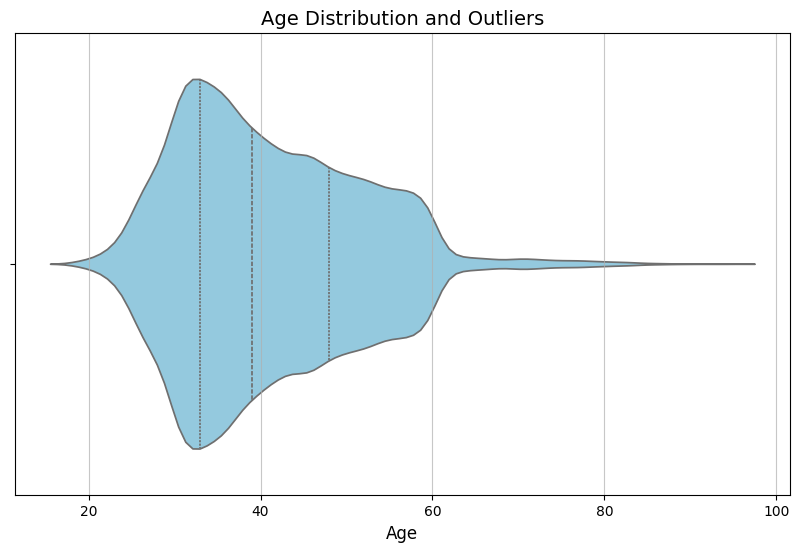

Min Age in Dataset: 18
Max Age in Dataset: 95


<Figure size 640x480 with 0 Axes>

In [174]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['age'], color='skyblue', inner='quartile')

plt.title('Age Distribution and Outliers', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.show()
plt.savefig('graphs/age_violin_plot.png')

print(f"Min Age in Dataset: {df['age'].min()}")
print(f"Max Age in Dataset: {df['age'].max()}")

The plot shows a massive bulge between 30 and 45. This is expected and is the target audience for the bank's marketing department.
The tail shows the older outliers who are people over 65-70 years old.

I will need to use a different scaling mechanism for these features.

### Balance

Like age, the bank balance feature is very likely to contain outliers.

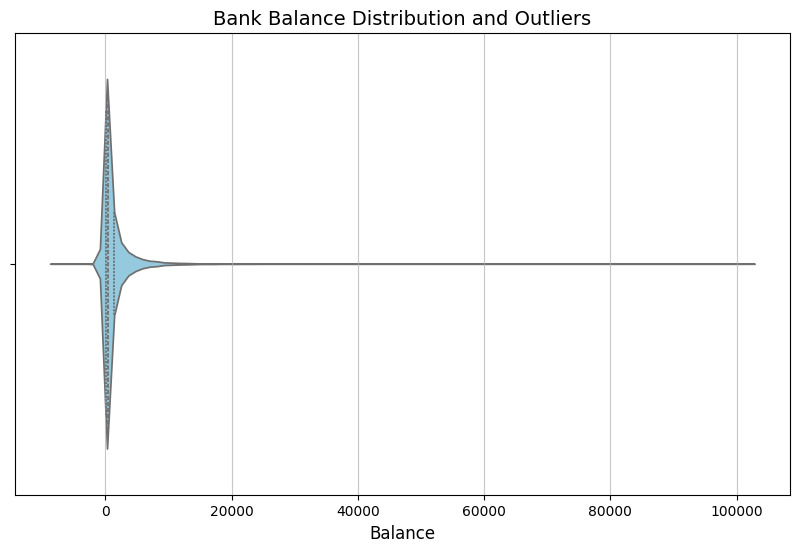

Min Balance in Dataset: -8019
Max Balance in Dataset: 102127


<Figure size 640x480 with 0 Axes>

In [175]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['balance'], color='skyblue', inner='quartile')

plt.title('Bank Balance Distribution and Outliers', fontsize=14)
plt.xlabel('Balance', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.show()
plt.savefig('graphs/balance_violin_plot.png')

print(f"Min Balance in Dataset: {df['balance'].min()}")
print(f"Max Balance in Dataset: {df['balance'].max()}")

As expected, there is a massive variance in the balances of those called by the banks marketeers.

### Campaign

This is the number of times that a person was called during the merketing campaign.<br>
From the initial analysis using df.describe, there also appears to be some outliers in the campaign feature. 

While it's somewhat excessive, the maximum number of calls made to a person was 63!<br>
There are a fair few outliers, so thsi column should also be scaled using a different mechanism.

In [176]:
# Filter the dataframe to > 30 calls, then count
over_30_count = df[df['campaign'] > 30]['campaign'].value_counts().sort_index()

print(over_30_count)

campaign
31    12
32     9
33     6
34     5
35     4
36     4
37     2
38     3
39     1
41     2
43     3
44     1
46     1
50     2
51     1
55     1
58     1
63     1
Name: count, dtype: int64


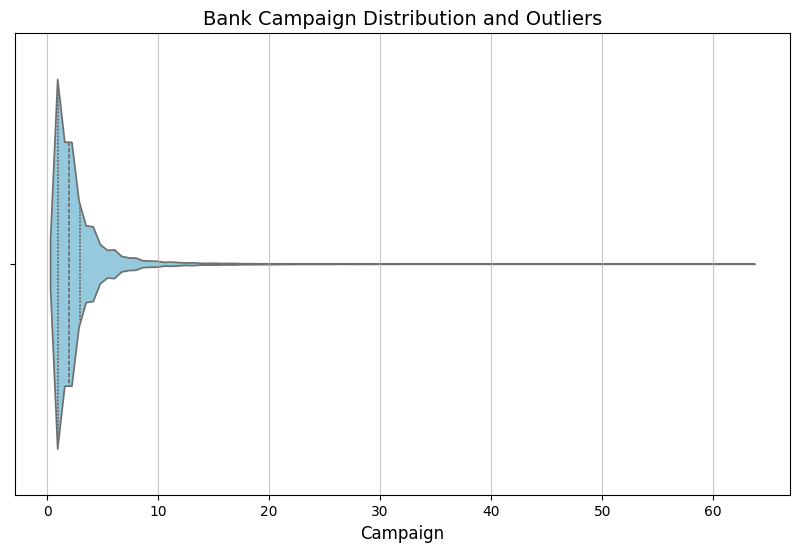

Min Campaign in Dataset: 1
Max Campaign in Dataset: 63


<Figure size 640x480 with 0 Axes>

In [177]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['campaign'], color='skyblue', inner='quartile')

plt.title('Bank Campaign Distribution and Outliers', fontsize=14)
plt.xlabel('Campaign', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.7)
plt.show()
plt.savefig('graphs/campaign_violin_plot.png')

print(f"Min Campaign in Dataset: {df['campaign'].min()}")
print(f"Max Campaign in Dataset: {df['campaign'].max()}")

### Encoding Columns with Outliers

To encode the age, balance and campaign features, a Standardised Z-Score Scaler will be used. <br>
This centres the values around 0, which will be the mean. The standard deviation is used calculate the spread of values.

$x_{scaled} = \frac{x - \mu}{\sigma}$

In [178]:
outlier_cols = ['age', 'balance', 'campaign']

def standardize_column(data):
    mu = np.mean(data)
    sigma = np.std(data)
    return (data - mu) / sigma

# Encode the outlier columns using standardization
for col in outlier_cols:
    df[col] = standardize_column(df[col])

In [179]:
df.sample(5)[outlier_cols]

,age,balance,campaign
15586,1.230269,-0.364653,-0.569351
36248,-0.653211,-0.447419,-0.569351
26291,-0.841558,0.237370,-0.569351
14413,0.194355,-0.592260,0.076230
29232,1.606965,-0.044428,-0.569351


### Target Variable Y

Exploring the target data variable 'y' shows that there is bias in the dataset. The majority of people did not deposit funds.<br>
The success rate is actually very good for a cold calling telephone marketing campaign, although the dataset is quite old (from May 2008 to November 2010).

"The average cold-calling success rate in 2025 is 2.3%, almost half of what it was in 2024 (4.82%)."<br>
From https://www.cognism.com/blog/cold-calling-success-rates

This will likely cause some issues for the neural network because the weights will tend to shift to favour negative responses; there are not many instances of positive responses to learn from.

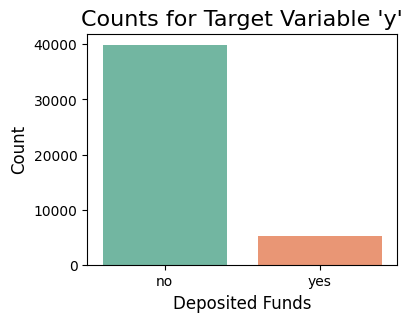

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


<Figure size 640x480 with 0 Axes>

In [180]:
plt.figure(figsize=(4,3))
sns.countplot(x='y', data=df, palette='Set2')
plt.title("Counts for Target Variable 'y'", fontsize=16)
plt.xlabel("Deposited Funds", fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
plt.savefig('graphs/target_y_count_plot.png')

# Print the percentage distribution of the target variable 'y'
print ((df['y'].value_counts(normalize=True) * 100).round(1))

### Pdays

The pdays feature requires special consideration. 

People who have never been called before are represented as -1.<br>
The rest of the data shows how long it has been since they were contacted previously.

It will likely show a bi-modal distribution, consisting of a dominant peak at -1 and a secondary distribution of values. These two groups represent different  behaviors. Therefore, applying a simple linear scaler to this data would not accurately capture the difference between these distinct groups. There would be a loss of meaning.

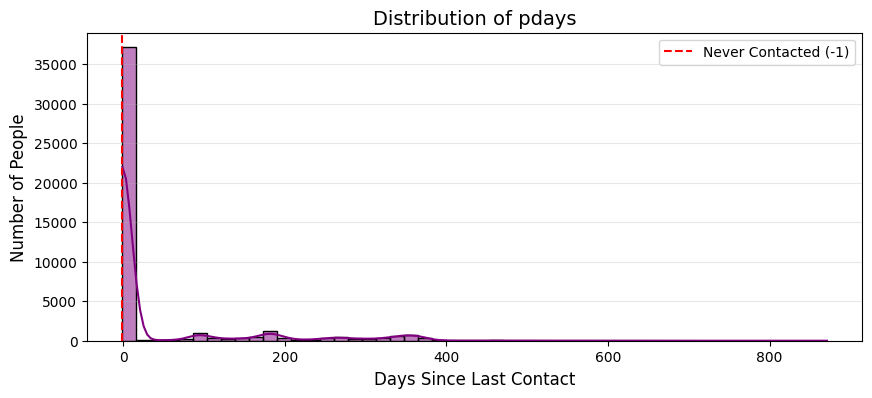

<Figure size 640x480 with 0 Axes>

In [181]:
plt.figure(figsize=(10, 4))

sns.histplot(df['pdays'], bins=50, kde=True, color='purple')

plt.axvline(x=-1, color='red', linestyle='--', label='Never Contacted (-1)')
plt.title('Distribution of pdays', fontsize=14)
plt.xlabel('Days Since Last Contact', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.savefig('graphs/pdays_histogram.png')

It is difficult to see the distribution of the positive values, so I have filtered out the uncontacted people:

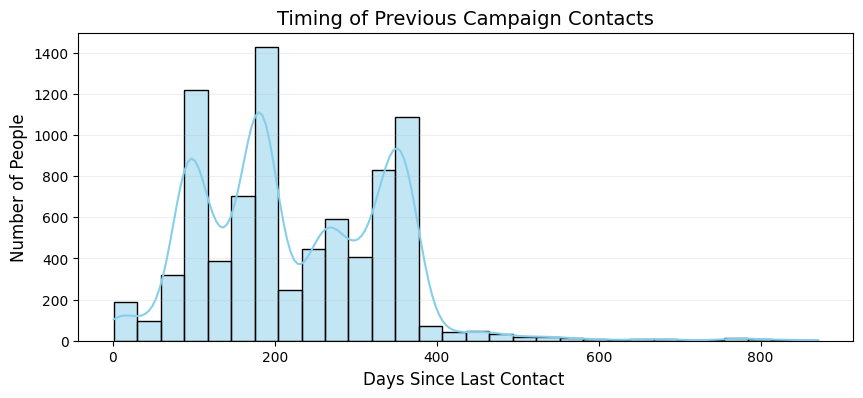

Average follow-up time: 224.58 days
Median follow-up time: 194.00 days


<Figure size 640x480 with 0 Axes>

In [182]:
# Create a filtered series without the -1 values
contacted_only = df[(df['pdays'] != -1)] ['pdays']

# Plot the distribution
plt.figure(figsize=(10, 4))
sns.histplot(contacted_only, bins=30, kde=True, color='skyblue')

plt.title('Timing of Previous Campaign Contacts', fontsize=14)
plt.xlabel('Days Since Last Contact ', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()
plt.savefig('graphs/pdays_contacted_only_histogram.png')

print(f"Average follow-up time: {contacted_only.mean():.2f} days")
print(f"Median follow-up time: {contacted_only.median():.2f} days")

The filtered pdays distribution is actually multi-modal, exhibiting several local maxima. These periodic peaks likely correspond to follow-up schedules such as 7-days, 14-days, 30-days etc. The feature 'time since last contact' is not a simple linear relationship, but a much more complicated feature where specific points in time are more significant than others. 

This feature will need to be treated differently again. It would be simplest to drop it from the model, however I feel that there is possibly useful meaning in including it. Afterall, who likes to be hassled by marketing phone calls? Does this not potentially imply some negative impact?

There are peaks at approximately 100, 180, 275 and 365 days. This suggests a re-engagement strategy based on quarterly cycles.<br>
To ensure the MLP captures these specific windows of opportunity, I will use a binning strategy based around these values:

In [183]:
def bins_for_pdays(val):
    if val == -1: return 0     # Never contacted
    if val <= 30: return 1     # Short term
    if val <= 150: return 2    # Captures 100 day peak
    if val <= 250: return 3    # Captures 180 day peak
    return 4                   # Longer term

df['pdays_binned'] = df['pdays'].apply(bins_for_pdays)

### Month

The month feature can be directly converted into a numeric field while maintaining meaning.<br>
There is a mathematical flaw in that the gap between December and January is '11', but in reality is only a single month.

If the MLP fails to learn sufficiently well, then this feature could be handled differently by representing the cyclical nature of the data using a sine function. However, even simple represented as values from 1 to 12 will be better than one hot encoding which woudl result in 12 new binary columns (and therefore input neurons).

In [184]:
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Apply the map to the 'month' column
df['month_numeric'] = df['month'].map(month_map)

# Check the result
print(df['month_numeric'].value_counts().sort_index())

month_numeric
1      1403
2      2649
3       477
4      2932
5     13766
6      5341
7      6895
8      6247
9       579
10      738
11     3970
12      214
Name: count, dtype: int64


### Day (of the month)

This column is unlikely to be useful unless there is a pattern in the data that aligns with a positive result, such as payday patterns.<br>
From the graphs below, this can likely be safely removed from the dataset.

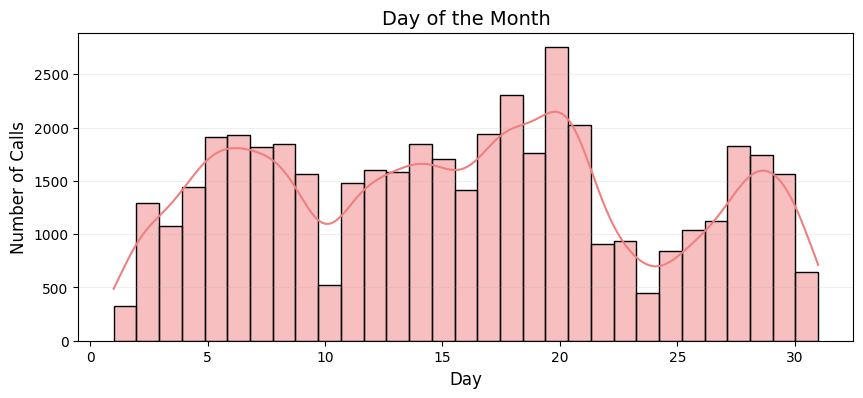

<Figure size 640x480 with 0 Axes>

In [185]:
# Plot the distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['day'], bins=31, kde=True, color='lightcoral')

plt.title('Day of the Month', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()
plt.savefig('graphs/days_of_month_histogram.png')

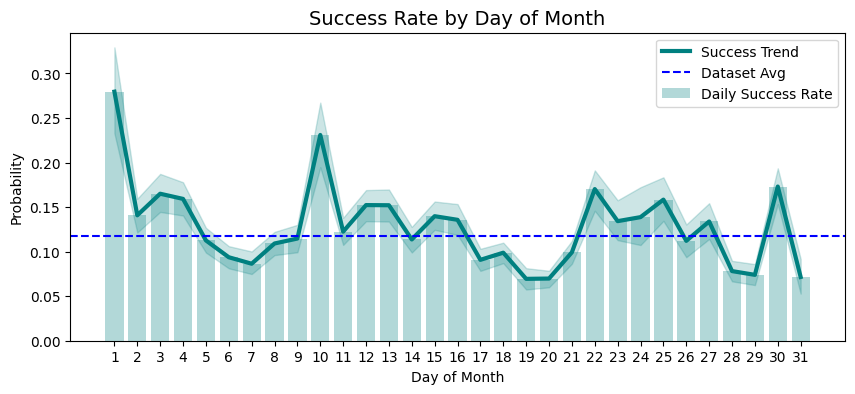

<Figure size 640x480 with 0 Axes>

In [186]:
# Ensure y is numeric - create temporary binary column for plotting
df['y_binary'] = df['y'].map({'yes': 1.0, 'no': 0.0}).astype(float)
day_stats = df.groupby('day')['y_binary'].mean()

plt.figure(figsize=(10, 4))

plt.bar(day_stats.index, day_stats.values, color='teal', alpha=0.3, label='Daily Success Rate')
sns.lineplot(x='day', y='y_binary', data=df, color='teal', linewidth=3, label='Success Trend')
plt.axhline(df['y_binary'].mean(), color='blue', linestyle='--', label='Dataset Avg')

plt.title('Success Rate by Day of Month', fontsize=14)
plt.xlabel('Day of Month')
plt.ylabel('Probability')
plt.xticks(range(1, 32))
plt.legend()

plt.show()
plt.savefig('graphs/success_rate_by_day.png')

# Tidy up the dataframe by removing the temporary binary column
df.drop(columns=['y_binary'], inplace=True)

### Duration

Duration is a problem because as well as being skewed with outliers (as shown in the following chart), it also allows for data leakage into the model.

If a person talks for 30 minutes, they have almost certainly already said "Yes". The longer duration is a result of positive intent, not a cause.<br>
Conversely, if they hang up after a very short time, then they are likely to have said "No".

The bank wants to use the  MLP to decide who to call tomorrow. Since they haven't called yet, they have no "duration" value to give the model.<br> 
The duration only becomes known *after* the decision has already been made, and entered into the target variable 'y'.

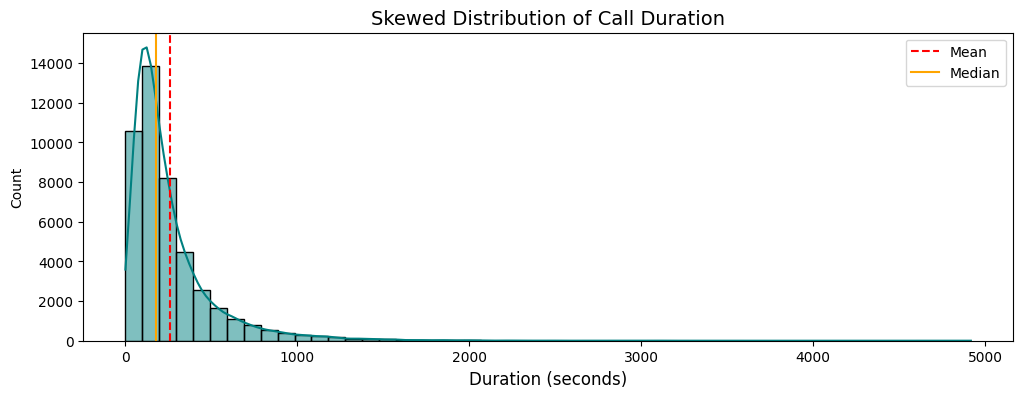

Skew: 3.14


<Figure size 640x480 with 0 Axes>

In [187]:
plt.figure(figsize=(12, 4))
sns.histplot(df['duration'], bins=50, kde=True, color='teal')

# Add marker lines for mean and median
plt.axvline(df['duration'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['duration'].median(), color='orange', linestyle='-', label='Median')

plt.title('Skewed Distribution of Call Duration', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.legend()
plt.show()
plt.savefig('graphs/duration_skew_histogram.png')

# Calculate the skew
print(f"Skew: {df['duration'].skew():.2f}")

### Default

This feature shows whether a person has a credit agreement that is 'in default'.<br>
The graph below shows that 98% of the people called are not in default.<br>
It is unlikely that the model will have sufficient examples of 'Yes' to learn from this field; it will be removed.

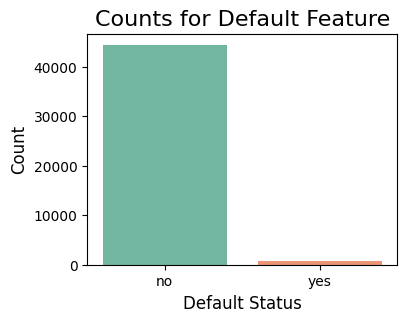

default
no     98.2
yes     1.8
Name: proportion, dtype: float64


<Figure size 640x480 with 0 Axes>

In [188]:
plt.figure(figsize=(4,3))
sns.countplot(x='default', data=df, palette='Set2')
plt.title("Counts for Default Feature", fontsize=16)
plt.xlabel("Default Status", fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
plt.savefig('graphs/default_count_plot.png')

# Print the percentage distribution of the target variable 'y'
print ((df['default'].value_counts(normalize=True) * 100).round(1))

### Remove Features

As described above, there are several features that are problematic and will be removed from the dataset.

|Feature	|Action	|Reasoning|
|--|--|--|
|Duration	|Dropped	|Target leakage; duration is not known at the time of prediction.|
|Default	|Dropped	|Near-zero variance; 98% of entries are 'no'.|
| Day | Dropped | Does not appear to add value; no obvious trends.|
|Pdays	|Binned Version Kept|	Re-encoded to handle multi-modal distribution and -1 values.|
|Month| Encoded version kept| Re-encoded as values 1-12|

In [189]:
# Columns to exclude from the dataset
excluded_features = ['duration','default', 'day', 'pdays', 'month']
df.drop(columns=excluded_features, inplace=True)

In [190]:
print(df.columns.sort_values())

Index(['age', 'balance', 'campaign', 'contact', 'education', 'housing', 'job',
       'loan', 'marital', 'month_numeric', 'pdays_binned', 'poutcome',
       'previous', 'y'],
      dtype='str')


### Encoding Binary Columns

In [191]:
binary_columns = ['housing', 'loan', 'y']

# Encode the Binary Features
for col in binary_columns:
    # Convert yes/no values to float versions
    df[col] = df[col].map({'yes': 1.0, 'no': 0.0}).astype(float)

### Define Normalisation Function

The goal is that all features contribute roughly equally to the training of the neural network.

$ x_scaled = \frac{x - min(x)}{max(x)-min(x)}$



In [192]:
numerical_cols = ['age', 'balance', 'campaign', 'pdays_binned', 'previous', 'month_numeric']
categorical_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

In [193]:
def max_min_normalize (df, column_name):
    max_value = df[column_name].max()
    min_value = df[column_name].min()
    df[column_name] = (df[column_name] - min_value) / (max_value - min_value)
    return df

In [ ]:
# Rewrite the normalization loop to use the function and not pass a whole df!
#for col in numerical_cols:

### Categorical Features - One Hot Encoding

In [194]:
# One Hot Encode the categorical features, resulting in True/False values for each category
df_one_hot = pd.get_dummies(df)

# Reencode these True/False values as floats
df_one_hot = df_one_hot.astype(float)
df_one_hot.sample(10)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,job_admin.,...,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
43624,-1.406602,-0.315716,0.0,0.0,-0.246560,0.0,1.0,0.0,5.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
39657,0.288529,0.220291,0.0,0.0,-0.569351,0.0,0.0,0.0,5.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21102,-0.841558,0.049176,0.0,1.0,0.399020,0.0,0.0,0.0,8.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
22987,-1.029906,-0.442493,0.0,1.0,-0.246560,0.0,0.0,0.0,8.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
12344,0.382703,-0.424100,0.0,0.0,-0.246560,0.0,0.0,0.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7692,0.947747,0.417025,0.0,0.0,-0.569351,0.0,0.0,0.0,5.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
28241,1.324443,-0.447419,0.0,0.0,-0.569351,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5298,-0.935732,1.486741,1.0,0.0,-0.569351,0.0,0.0,0.0,5.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
36293,0.382703,-0.297652,1.0,0.0,-0.569351,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
24371,1.136095,0.098113,1.0,1.0,-0.569351,0.0,0.0,0.0,11.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [195]:
# Scale each column, one at a time
for col in df_one_hot.columns.to_list():
    df_scaled = max_min_normalize(df_one_hot, col)

In [196]:
df_scaled.sample(10)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,job_admin.,...,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
35972,0.246753,0.076371,1.0,0.0,0.048387,0.007273,0.0,1.00,0.363636,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
17498,0.220779,0.072812,1.0,0.0,0.112903,0.000000,0.0,0.00,0.545455,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1215,0.363636,0.073212,1.0,0.0,0.000000,0.000000,0.0,0.00,0.363636,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
45173,0.233766,0.081701,0.0,0.0,0.048387,0.025455,0.0,0.50,0.909091,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
36073,0.220779,0.113794,1.0,0.0,0.032258,0.007273,0.0,0.75,0.363636,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
19946,0.389610,0.112887,1.0,0.0,0.080645,0.000000,0.0,0.00,0.636364,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
14350,0.376623,0.069798,1.0,0.0,0.048387,0.000000,0.0,0.00,0.545455,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
29371,0.233766,0.078305,1.0,0.0,0.016129,0.000000,0.0,0.00,0.090909,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
35340,0.389610,0.064287,1.0,0.0,0.000000,0.007273,0.0,1.00,0.363636,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
22016,0.337662,0.072803,0.0,0.0,0.064516,0.000000,0.0,0.00,0.636364,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Save the Dataframe
Write out the dataframe to files

In [197]:
# Create filenames, one timestamped, one 'latest'
filepath = "."

filename = f'{filepath}/bank_full_scaled_{now_date_timestamp}.csv'
latest_filename = f'{filepath}/bank_full_scaled_latest.csv'

# Write out CSV files
df_scaled.to_csv(filename, index=False)
df_scaled.to_csv(latest_filename, index=False)